**Student Performance Analysis**

In [1]:
!pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB 330.3 kB/s eta 0:00:06
   - -------------------------------------- 0.1/2.0 MB 825.8 kB/s eta 0:00:03
   --- ------------------------------------ 0.2/2.0 MB 1.5 MB/s eta 0:00:02
   ----- ---------------------------------- 0.3/2.0 MB 1.4 MB/s eta 0:00:02
   ------ --------------------------------- 0.3/2.0 MB 1.4 MB/s eta 0:00:02
   -------- ------------------------------- 0.4/2.0 MB 1.5 MB/s eta 0:00:02
   --------- ------------------------------ 0.5/2.0 MB 1.5 MB/s eta 0:00:01
   ------------ --------------------------- 0.6/2.0 MB 1.7 MB/s eta 0:00:01
   -------------- ------------------------- 0.7/2.0 MB 1.7 MB/s eta 0:00:01
   ---------------- ----------------------- 0.8/2.0 MB 1.8 MB/s eta 0:00:01
   ------------------ --------------------- 0.9/2.0 MB 1.8 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.0 MB 1.8 MB/s eta 0:00:01
   ------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from faker import Faker
fake = Faker()

In [3]:
np.random.seed(0)

Initializing the dataset

In [4]:
data = {
    "Student_ID": np.random.choice(np.arange(1000, 9999), size=250, replace=False),
    "Name": [fake.name() for i in range(250)],
    "Gender": np.random.choice(["Male", "Female"], size=250),
    "Department": np.random.choice(["CSE", "IT", "ECE"], size=250),
    "Year": np.random.choice([1, 2, 3], size=250),
    "Math_Marks": np.random.randint(0, 101, size=250),
    "Science_Marks": np.random.randint(0, 101, size=250),
    "English_Marks": np.random.randint(0, 101, size=250),
    "Attendance": np.random.randint(50, 101, size=250),
    "Internals_Marks": np.random.randint(0, 26, size=250)
}

In [5]:
data = pd.DataFrame(data)
data

,Student_ID,Name,Gender,Department,Year,Math_Marks,Science_Marks,English_Marks,Attendance,Internals_Marks
0,5424,Jasmine Salinas,Female,IT,3,55,28,46,52,9
1,2726,Edward Wright,Female,CSE,1,79,9,94,68,17
2,8894,Kristen Mata,Male,CSE,3,52,38,27,85,15
3,8803,Andrea Michael,Male,ECE,3,67,77,53,90,21
4,2986,Andrew Rojas,Male,IT,3,79,26,68,60,19
...,...,...,...,...,...,...,...,...,...,...
245,4538,Lawrence Wells,Female,CSE,1,100,93,14,54,4
246,1760,Melissa Morris,Female,ECE,3,96,30,88,91,12
247,6504,John Hicks,Female,ECE,1,43,10,9,50,16
248,6161,Dr. Gregory Campbell PhD,Female,IT,3,100,35,22,80,12


Mean

In [6]:
print("Means:\n")
print(data[['Math_Marks', 'Science_Marks', 'English_Marks']].mean())

Means:

Math_Marks       52.952
Science_Marks    50.964
English_Marks    53.544
dtype: float64


Median

In [7]:
print("Medians:\n")
print(data[['Math_Marks', 'Science_Marks', 'English_Marks']].median())

Medians:

Math_Marks       54.0
Science_Marks    49.0
English_Marks    56.0
dtype: float64


Modes

In [8]:
print("Modes:\n")
print(data[['Math_Marks', 'Science_Marks', 'English_Marks']].mode().iloc[0])

Modes:

Math_Marks       43
Science_Marks    81
English_Marks    22
Name: 0, dtype: int32


Standard Deviation

In [9]:
print("Standard Deviation:\n")
print(data[['Math_Marks', 'Science_Marks', 'English_Marks']].std())

Standard Deviation:

Math_Marks       28.597569
Science_Marks    28.634568
English_Marks    29.560503
dtype: float64


Total Marks and Average

In [10]:
data["Total_Marks"] = data["Math_Marks"] + data["Science_Marks"] + data["English_Marks"]

data["Average"] = data["Total_Marks"] / 3

data

,Student_ID,Name,Gender,Department,Year,Math_Marks,Science_Marks,English_Marks,Attendance,Internals_Marks,Total_Marks,Average
0,5424,Jasmine Salinas,Female,IT,3,55,28,46,52,9,129,43.000000
1,2726,Edward Wright,Female,CSE,1,79,9,94,68,17,182,60.666667
2,8894,Kristen Mata,Male,CSE,3,52,38,27,85,15,117,39.000000
3,8803,Andrea Michael,Male,ECE,3,67,77,53,90,21,197,65.666667
4,2986,Andrew Rojas,Male,IT,3,79,26,68,60,19,173,57.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
245,4538,Lawrence Wells,Female,CSE,1,100,93,14,54,4,207,69.000000
246,1760,Melissa Morris,Female,ECE,3,96,30,88,91,12,214,71.333333
247,6504,John Hicks,Female,ECE,1,43,10,9,50,16,62,20.666667
248,6161,Dr. Gregory Campbell PhD,Female,IT,3,100,35,22,80,12,157,52.333333


Grades

In [11]:
def grade(avg):
    if avg >= 90:
        return "A"
    elif avg >= 75:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 50:
        return "D"
    else:
        return "Fail"

data["Grade"] = data["Average"].apply(grade)

data

,Student_ID,Name,Gender,Department,Year,Math_Marks,Science_Marks,English_Marks,Attendance,Internals_Marks,Total_Marks,Average,Grade
0,5424,Jasmine Salinas,Female,IT,3,55,28,46,52,9,129,43.000000,Fail
1,2726,Edward Wright,Female,CSE,1,79,9,94,68,17,182,60.666667,C
2,8894,Kristen Mata,Male,CSE,3,52,38,27,85,15,117,39.000000,Fail
3,8803,Andrea Michael,Male,ECE,3,67,77,53,90,21,197,65.666667,C
4,2986,Andrew Rojas,Male,IT,3,79,26,68,60,19,173,57.666667,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,4538,Lawrence Wells,Female,CSE,1,100,93,14,54,4,207,69.000000,C
246,1760,Melissa Morris,Female,ECE,3,96,30,88,91,12,214,71.333333,C
247,6504,John Hicks,Female,ECE,1,43,10,9,50,16,62,20.666667,Fail
248,6161,Dr. Gregory Campbell PhD,Female,IT,3,100,35,22,80,12,157,52.333333,D


Top Performing Students

In [12]:
top_students = data.sort_values(by="Total_Marks", ascending=False).head(10)

print("Top 10 Students")
print(top_students[["Name","Department","Total_Marks","Grade"]])

Top 10 Students
                  Name Department  Total_Marks Grade
25       Steven Chavez         IT          277     A
59   Jacqueline Davila        ECE          258     B
108     Charles Barker        CSE          258     B
11       Anthony Smith        ECE          257     B
121     Christy Fuller         IT          256     B
46        John Houston        CSE          249     B
197    Dustin Williams         IT          249     B
178      Sylvia Mendez        CSE          249     B
165        Manuel Kent        ECE          248     B
71      Mark Rodriguez        CSE          244     B


Low Performing Students

In [13]:
low_students = data[data["Grade"] == "Fail"]

print("Low Performing Students")
print(low_students[["Name","Department","Total_Marks","Grade"]])

Low Performing Students
                Name Department  Total_Marks Grade
0    Jasmine Salinas         IT          129  Fail
2       Kristen Mata        CSE          117  Fail
6     Renee Shepherd         IT           98  Fail
8    Thomas Williams         IT           93  Fail
9        Kevin Small        CSE          149  Fail
..               ...        ...          ...   ...
242      Joy Schmidt        CSE          115  Fail
243       Kurt Wells        CSE           97  Fail
244       Eric Salas        ECE           49  Fail
247       John Hicks        ECE           62  Fail
249   Erica Alvarado        CSE          111  Fail

[104 rows x 4 columns]


Department-wise Analysis

  Department    Average
0        CSE  52.750000
1        ECE  52.085470
2         IT  52.590909


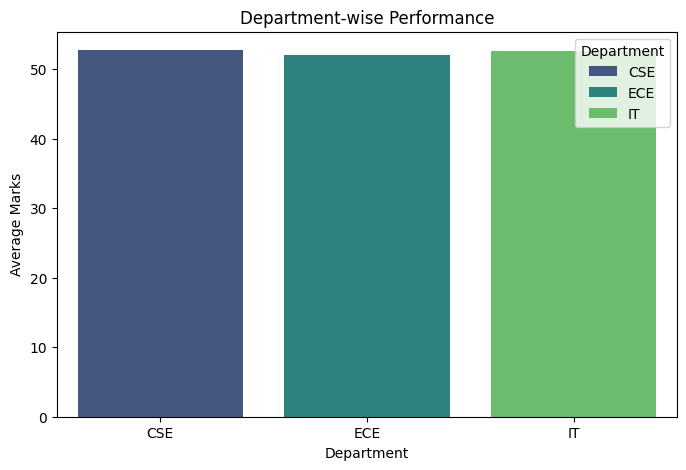

In [14]:
department_wise = data.groupby("Department")["Average"].mean().reset_index()

print(department_wise)

plt.figure(figsize=(8, 5))
sns.barplot(x="Department", y="Average", data=department_wise, palette="viridis", hue="Department", legend=True)
plt.title("Department-wise Performance")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

Year-wise Analysis


   Year    Average
0     1  54.395349
1     2  51.658009
2     3  51.333333


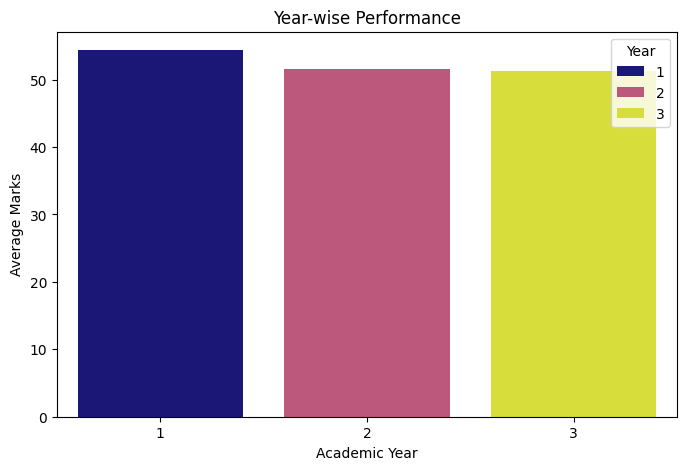

In [15]:
year_wise = data.groupby("Year")["Average"].mean().reset_index()

print(year_wise)

plt.figure(figsize=(8, 5))
sns.barplot(x="Year", y="Average", data=year_wise, palette="plasma", hue="Year", legend=True)
plt.title("Year-wise Performance")
plt.xlabel("Academic Year")
plt.ylabel("Average Marks")
plt.show()

Gender-wise Performance

   Gender    Average
0  Female  52.330579
1    Male  52.633075


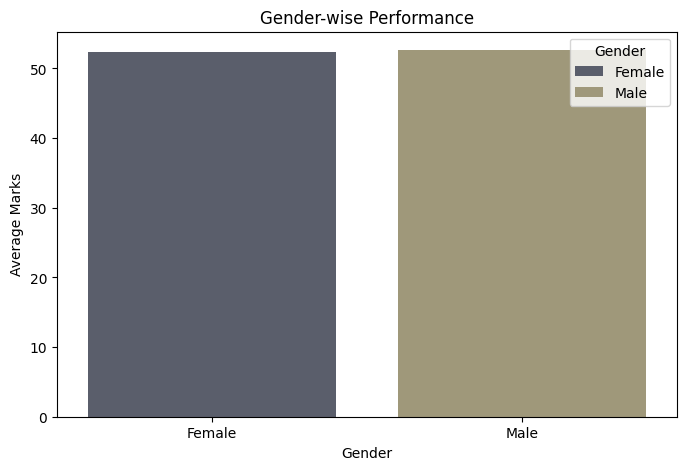

In [16]:
gender_perf = data.groupby("Gender")["Average"].mean().reset_index()

print(gender_perf)

plt.figure(figsize=(8, 5))
sns.barplot(x="Gender", y="Average", data=gender_perf, palette="cividis", hue="Gender", legend=True)
plt.title("Gender-wise Performance")
plt.xlabel("Gender")
plt.ylabel("Average Marks")
plt.show()

Attendance vs Average

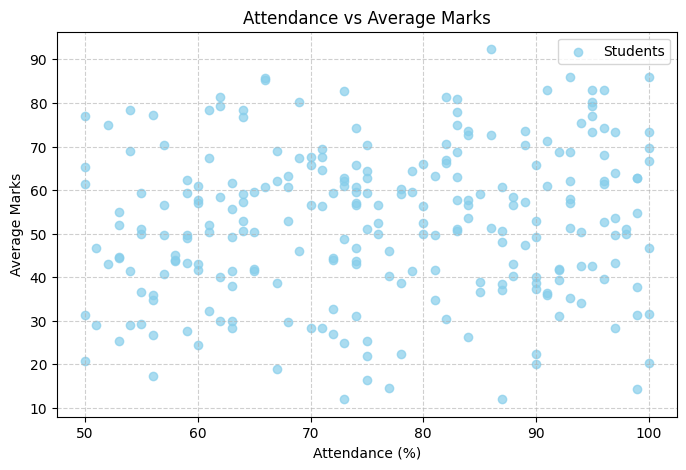

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Attendance"], data["Average"], alpha=0.7, c='skyblue', label='Students')
plt.title("Attendance vs Average Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Marks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Internals Marks vs Average Marks

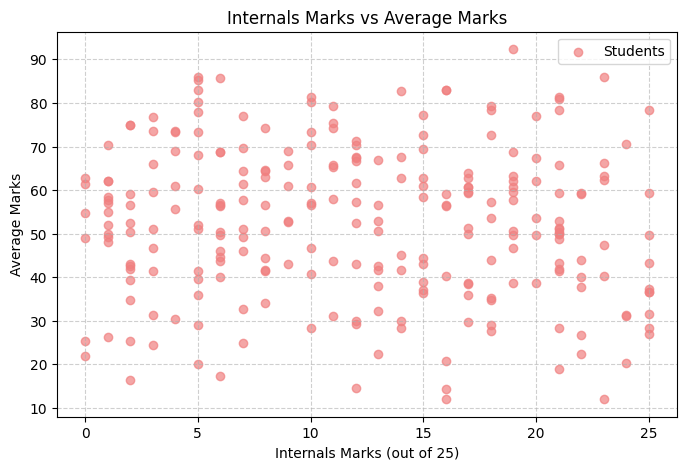

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Internals_Marks"], data["Average"], alpha=0.7, c='lightcoral', label='Students')
plt.title("Internals Marks vs Average Marks")
plt.xlabel("Internals Marks (out of 25)")
plt.ylabel("Average Marks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Grade Pie chart

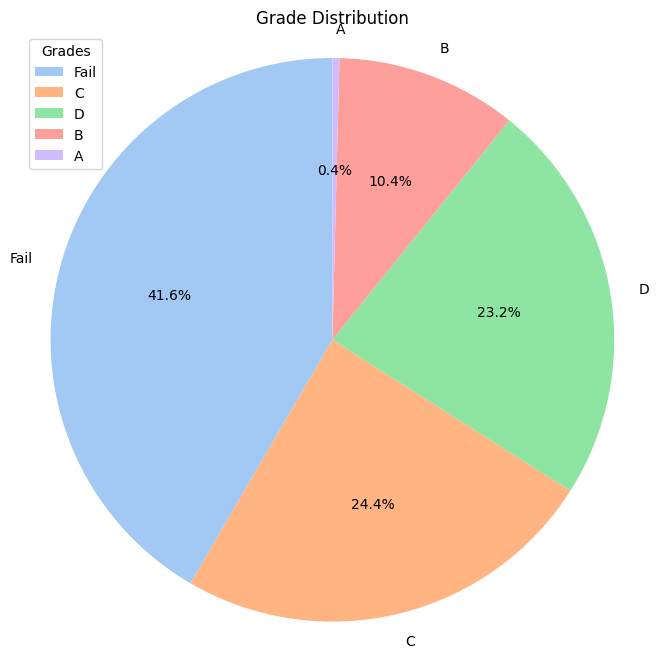

In [19]:
grade_count = data["Grade"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(grade_count, labels=grade_count.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Grade Distribution")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(title='Grades', loc='best')
plt.show()

Distribution of Average marks

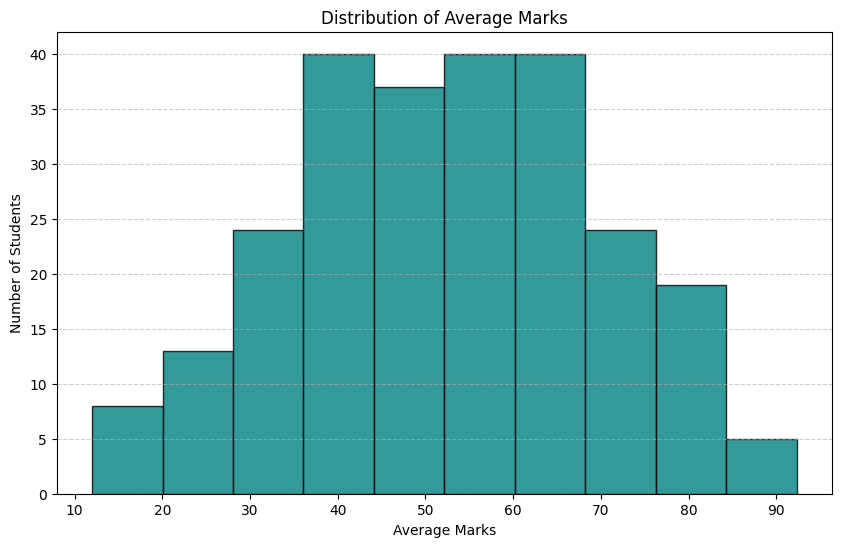

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(data["Average"], bins=10, color='teal', edgecolor='black', alpha=0.8)
plt.title("Distribution of Average Marks")
plt.xlabel("Average Marks")
plt.ylabel("Number of Students")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Creation of CSV file

In [21]:
data.to_csv("student_performance.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully
